In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [3]:
data = datasets.load_digits()

In [4]:
data

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
data.images.shape # 8 x 8 pixels (very blocky)

(1797, 8, 8)

6


(-0.5, 7.5, 7.5, -0.5)

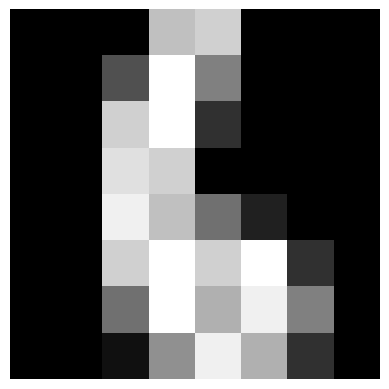

In [10]:
N = 6
print(data.target[N])
im = data.images[N, :, :]
plt.imshow(im, cmap='gray')
plt.axis('off')

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier #multi-layer perceptron -> neurons used to be called multi-layer perceptron


In [17]:

x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3) #target = output

In [14]:
x_train.shape

(1257, 64)

In [15]:
x_test.shape

(540, 64)

In [43]:
model = MLPClassifier() #hyper parameter tuning 
#when it comes to neural networks, the defaults are not very good

In [44]:
model.fit(x_train, y_train)

MLPClassifier()

In [22]:
y_pred = model.predict(x_test)

In [ ]:
y_pred[0:10] #predictions

array([2, 9, 5, 5, 7, 3, 0, 3, 9, 7])

In [24]:
y_test[0:10] #actual values

array([2, 9, 5, 5, 7, 3, 0, 3, 9, 7])

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

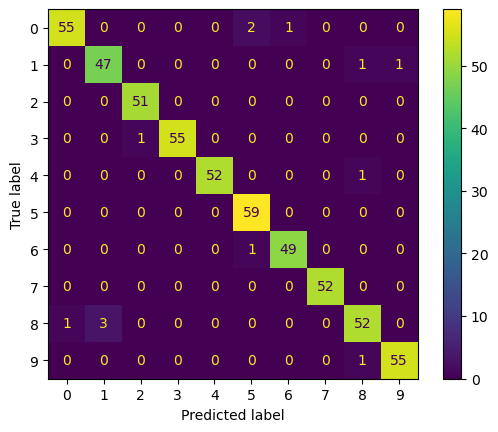

In [34]:
im = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(im).plot()

In [35]:
print(classification_report(y_test, y_pred))
#percision - how many of the predicted values were correct (55/57)
#recall - how many of the actual values were predicted correctly (55/)
#oneis useful in one scenario and the other is useful in another

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.94      0.96      0.95        49
           2       0.98      1.00      0.99        51
           3       1.00      0.98      0.99        56
           4       1.00      0.98      0.99        53
           5       0.95      1.00      0.98        59
           6       0.98      0.98      0.98        50
           7       1.00      1.00      1.00        52
           8       0.95      0.93      0.94        56
           9       0.98      0.98      0.98        56

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



In [45]:
model.score(x_test, y_test) #accuracy

0.9703703703703703

FINE TUNING

In [66]:
model = MLPClassifier(activation='logistic', hidden_layer_sizes=200) #hidden layer sizes = number of neurons in each layer
model.fit(x_train, y_train)
model.score(x_test, y_test) #accuracy


0.9814814814814815

In [87]:
model = MLPClassifier(activation='logistic', learning_rate='adaptive', hidden_layer_sizes=200) #hidden layer sizes = number of neurons in each layer
model.fit(x_train, y_train)
model.score(x_test, y_test) #accuracy


0.9814814814814815

In [102]:
model = MLPClassifier(activation='logistic', learning_rate='adaptive', hidden_layer_sizes=(1000,1000,1000,)) #hidden layer sizes = number of neurons in each layer
model.fit(x_train, y_train)
model.score(x_test, y_test) #accuracy

0.975925925925926